### Modeling:  Clustering using AGNES

Goals : Cluster scaled audio features and try to find clusters to find similar type of music, the idea is that we will find clusters of different styles of music and flag outliers, those clusters will help us during the recommendation process

> I've used K-Means many times before but for this analysis I think AGNES would be better :
> 1. gamers usually plays many games in the same style so the clustering using distance will be influenced too much by the initialization of k-means
> 2. the number of cluster depends on the player and there is too many different styles of music so trying different n might be efficient
> 3. AGNES uses an agglomerative is ideal for naturally capturing micro-communities and niche sub-genres first, before smoothly grouping them into broader, overarching gaming and music archetypes.

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

> Infinite values appeared because some preprocessing produced non-finite results (e.g., division by zero during our min-max scaling or malformed API payloads returning Infinity)

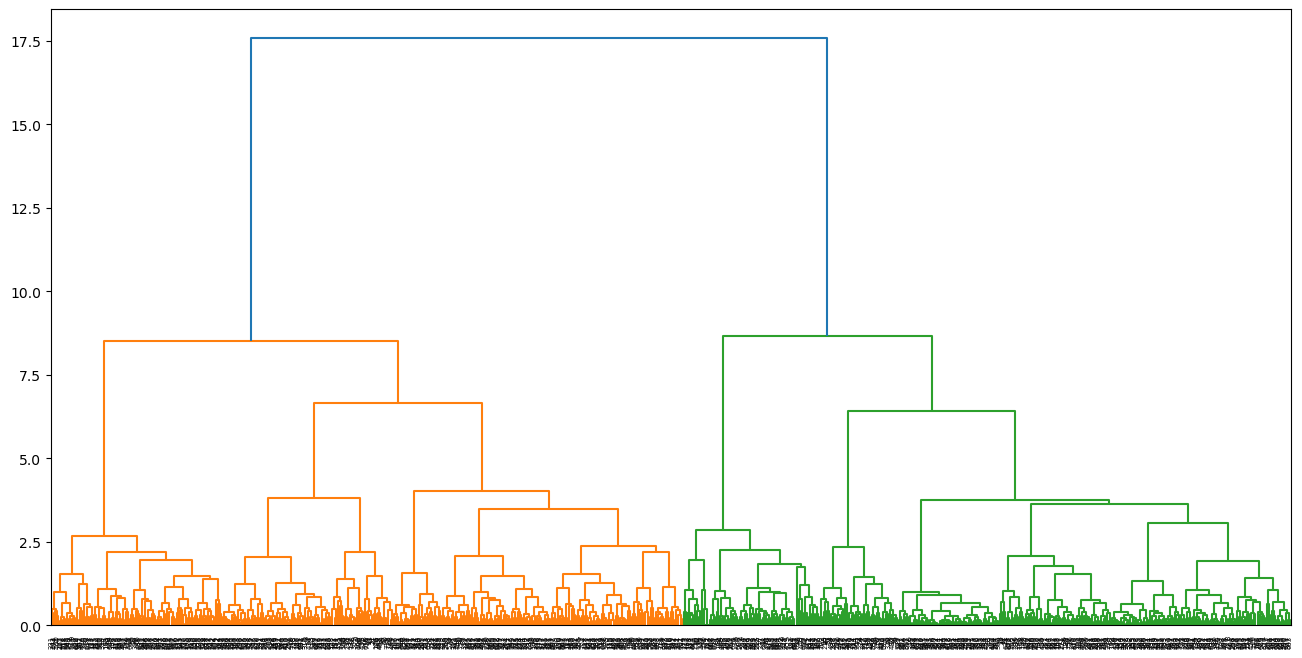

In [22]:
df = pd.read_csv("../data/rapidapi_features_scaled.csv")
features = ["danceability","energy","valence","acousticness","instrumentalness","liveness","speechiness","tempo"]
X = df[features].replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
 

Z = linkage(X, "ward")

plt.figure(figsize=(16,8))
dn = dendrogram(Z)
plt.show()


> The vertical axis of the dendrogram measures the dissimilarity between groups, the higher up a horizontal split occurs, the more distinct those player profiles are from one another. If we prioritize the most fundamental, large-scale behavioral split, choosing **2 clusters** (cutting around height 12.0) is ideal because it intersects the two longest vertical branches, separating the data into two highly distinct macro-archetypes. Alternatively, if we want more granular profiles, choosing **6 clusters** (cutting around height 5.0) is a strategic choice that balances complexity and detail, at this threshold, the orange macro-branch cleanly splits into 2 tighter sub-clusters and the green branch into 4, maximizing similarity within each group without creating excessive noise.

In [24]:
for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"For k={k}, Silhouette Score is {score:.4f}")

For k=2, Silhouette Score is 0.3226
For k=3, Silhouette Score is 0.2894
For k=4, Silhouette Score is 0.2687
For k=5, Silhouette Score is 0.2504
For k=6, Silhouette Score is 0.2535


> This bounce-back indicates that at 6 clusters, the model achieves significantly better internal cohesion and cluster separation, resulting in more distinct and well-defined groups. In our context, finding 6 unique styles of music and gaming behaviors is highly realistic and expected, which mathematically and practically justifies our choice of K=6

> Let's now assign cluster labels based with 6 clusters :

In [ ]:
agnes_model = AgglomerativeClustering(n_clusters=6, linkage='ward')

df['cluster'] = agnes_model.fit_predict(X)

> Let's now visualize if our labeling has clear outlines, for that we're gonna use U-MAP in order to preserve local structure of our musics and since music features are complex data that depends a lot on user, they could be non-linear which PCA doesn't capture

In [28]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


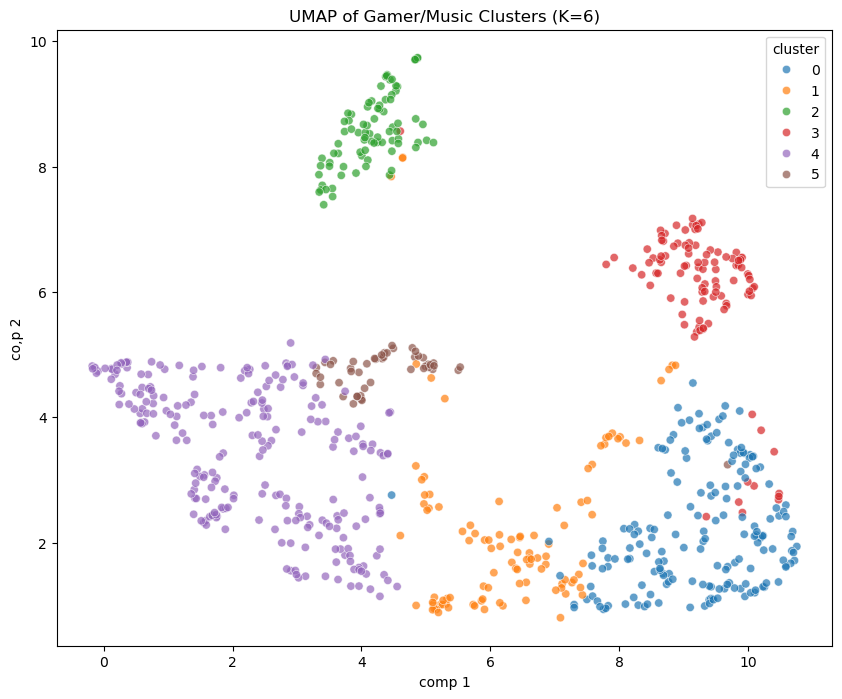

In [32]:
import umap
import seaborn as sns

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embed = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embed[:, 0],  y=embed[:, 1], hue=df['cluster'], palette='tab10', alpha=0.7)
plt.title('UMAP of Gamer/Music Clusters (K=6)')
plt.xlabel('comp 1')
plt.ylabel('co,p 2')
plt.show()

> The UMAP projection perfectly validates our 6-cluster AGNES model, showing highly distinct behavioral groups with minimal noise. Clusters 2 (green) and 3 (red) form completely isolated islands, meaning they represent highly specialized, distinct gaming and music style/genre. Meanwhile, the smooth transition from cluster 4 to 5, 1, and 0 captures a natural spectrum: music isn't just "sad" or "happy". This proves that K=6 successfully isolates unique bridge communities rather than forcing arbitrary splits. Overall, the clear separation confirms the model is highly meaningful which is a win for real-world data!